## Loan Default Prediction

In [1]:
import pandas as pd

In [2]:
# load the data 
df = pd.read_csv(r"C:\Users\user\Desktop\Loan_default.csv\Loan_default.csv")
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [3]:
df.shape

(255347, 18)

In [5]:
df.columns.tolist()

['LoanID',
 'Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [8]:
df.sample(10)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
118455,S09HU2M9SH,62,39350,204450,515,90,1,17.16,12,0.43,PhD,Part-time,Divorced,No,No,Auto,No,0
230155,4HEYAC0373,46,20358,128698,539,32,3,24.85,24,0.42,Bachelor's,Self-employed,Divorced,No,Yes,Business,Yes,0
79629,XX86JGH65L,34,134234,174972,324,96,1,20.55,24,0.24,Bachelor's,Self-employed,Single,Yes,Yes,Business,Yes,0
151511,IE4N672UEB,58,80045,96144,707,77,1,18.23,60,0.56,High School,Full-time,Single,No,Yes,Business,No,0
59377,CJI0XX3RC8,28,64917,115969,585,3,2,21.70,60,0.42,PhD,Part-time,Single,No,No,Auto,Yes,0
185522,GW6LRHDUH2,40,120489,5165,435,116,3,17.39,12,0.90,Bachelor's,Unemployed,Married,No,No,Business,Yes,0
168990,LPY0ZZ32GE,57,133751,99445,747,86,2,24.14,24,0.51,Bachelor's,Part-time,Single,No,No,Education,No,0
241145,BMF01SEA8J,37,49687,229962,638,75,3,19.31,60,0.83,Master's,Full-time,Married,No,Yes,Education,No,0
204442,8K0M8S4HV6,57,111170,139210,336,85,4,19.32,60,0.59,Bachelor's,Part-time,Married,Yes,No,Education,Yes,0
59926,BVJNYWD5KS,54,117352,63378,597,23,2,3.92,36,0.88,Bachelor's,Part-time,Married,Yes,No,Business,Yes,0


In [9]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [10]:
df.describe(include ='all')

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347,255347,255347,255347,255347,255347,255347,255347.000000
unique,255347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,2,2,5,2,NaN
top,ZTH91CGL0B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64366,64161,85302,127677,127742,51298,127701,NaN
mean,NaN,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116128
std,NaN,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.320379
min,NaN,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [12]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.nunique()

LoanID            255347
Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64

In [18]:
df.nunique().sort_values()

HasMortgage            2
HasDependents          2
Default                2
HasCoSigner            2
MaritalStatus          3
Education              4
EmploymentType         4
NumCreditLines         4
LoanTerm               5
LoanPurpose            5
Age                   52
DTIRatio              81
MonthsEmployed       120
CreditScore          550
InterestRate        2301
Income            114620
LoanAmount        158729
LoanID            255347
dtype: int64

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df['Default'].value_counts(normalize=True)*100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

<Axes: xlabel='Default', ylabel='CreditScore'>

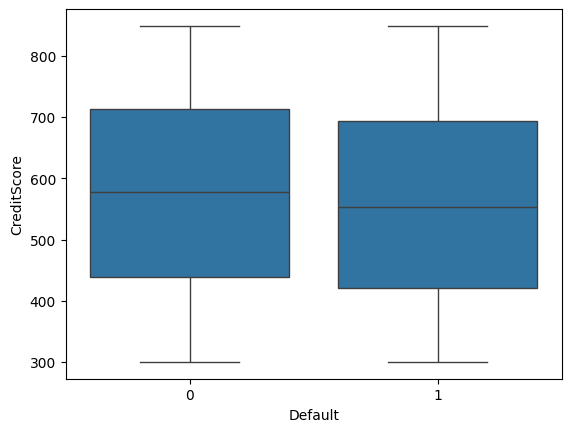

In [27]:
sns.boxplot(data=df, x='Default', y='CreditScore')

<Axes: xlabel='Default', ylabel='DTIRatio'>

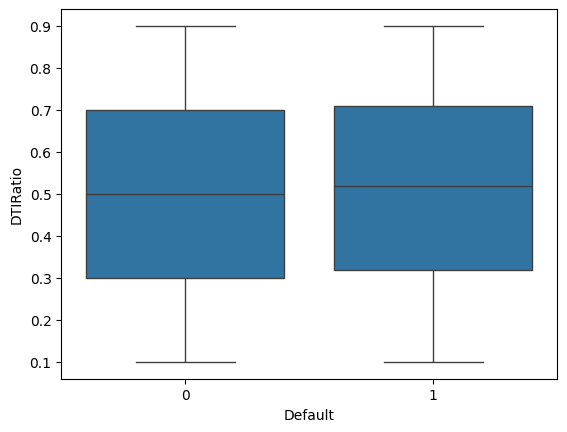

In [28]:
sns.boxplot(data=df, x='Default', y='DTIRatio')

,Income,LoanAmount,Age
Income,1.000000,-0.000865,-0.001244
LoanAmount,-0.000865,1.000000,-0.002213
Age,-0.001244,-0.002213,1.000000


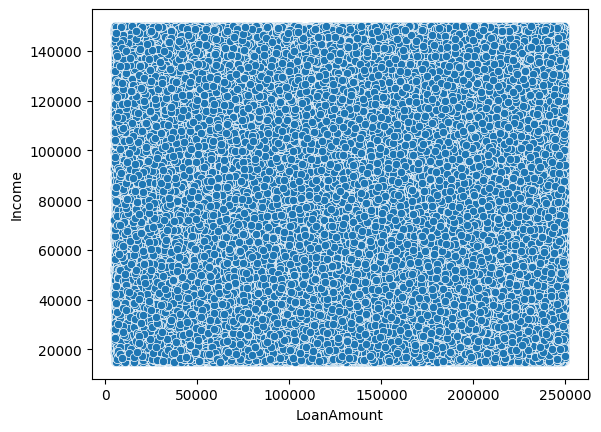

In [25]:
sns.scatterplot(data=df, x='LoanAmount', y='Income')
df[['Income','LoanAmount','Age']].corr()

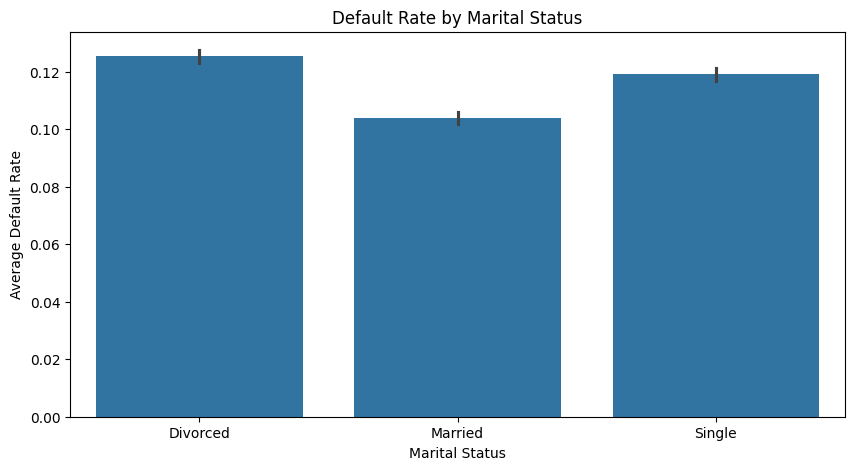

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='MaritalStatus', y='Default')
plt.title('Default Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Average Default Rate')
plt.show()

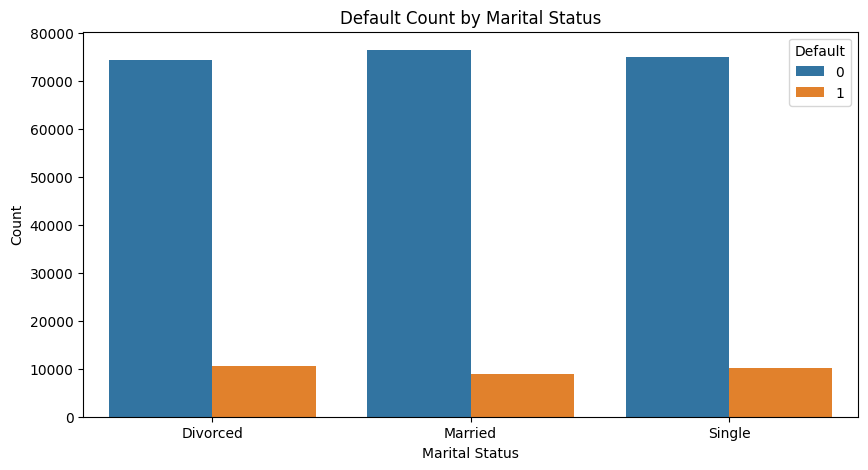

Default                0          1
MaritalStatus                      
Divorced       87.467219  12.532781
Married        89.602823  10.397177
Single         88.087564  11.912436


In [24]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='MaritalStatus', hue='Default')
plt.title('Default Count by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

(pd.crosstab(df['MaritalStatus'], df['Default'], normalize='index') * 100)
print(table)